In [1]:
#option analysis code
from pathlib import Path
import numpy as np
import tifffile
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

files = {
    "delta0":   Path("/Users/sunxiaoyuamanda/Desktop/summer project/7.30 qwp decomp result/sample0/retardance_deg.tiff"),
    "delta20":  Path("/Users/sunxiaoyuamanda/Desktop/summer project/7.30 qwp decomp result/sample20/retardance_deg.tiff"),
    "delta40":  Path("/Users/sunxiaoyuamanda/Desktop/summer project/7.30 qwp decomp result/sample40/retardance_deg.tiff"),
    "delta60":  Path("/Users/sunxiaoyuamanda/Desktop/summer project/7.30 qwp decomp result/sample60/retardance_deg.tiff"),
    "delta80":  Path("/Users/sunxiaoyuamanda/Desktop/summer project/7.30 qwp decomp result/sample80/retardance_deg.tiff"),
    "delta90":  Path("/Users/sunxiaoyuamanda/Desktop/summer project/7.30 qwp decomp result/sample90/retardance_deg.tiff"),
    "delta100":  Path("/Users/sunxiaoyuamanda/Desktop/summer project/7.30 qwp decomp result/sample100/retardance_deg.tiff"),
    "delta120":  Path("/Users/sunxiaoyuamanda/Desktop/summer project/7.30 qwp decomp result/sample120/retardance_deg.tiff"),
    "delta140":  Path("/Users/sunxiaoyuamanda/Desktop/summer project/7.30 qwp decomp result/sample140/retardance_deg.tiff"),
    "delta160":  Path("/Users/sunxiaoyuamanda/Desktop/summer project/7.30 qwp decomp result/sample160/retardance_deg.tiff"),
    

    "orientation0":   Path("/Users/sunxiaoyuamanda/Desktop/summer project/7.30 qwp decomp result/sample0/orientation_deg.tiff"),
    "orientation20":  Path("/Users/sunxiaoyuamanda/Desktop/summer project/7.30 qwp decomp result/sample20/orientation_deg.tiff"),
    "orientation40":  Path("/Users/sunxiaoyuamanda/Desktop/summer project/7.30 qwp decomp result/sample40/orientation_deg.tiff"),
    "orientation60":  Path("/Users/sunxiaoyuamanda/Desktop/summer project/7.30 qwp decomp result/sample60/orientation_deg.tiff"),
    "orientation80":  Path("/Users/sunxiaoyuamanda/Desktop/summer project/7.30 qwp decomp result/sample80/orientation_deg.tiff"),
    "orientation90":  Path("/Users/sunxiaoyuamanda/Desktop/summer project/7.30 qwp decomp result/sample90/orientation_deg.tiff"),
    "orientation100":  Path("/Users/sunxiaoyuamanda/Desktop/summer project/7.30 qwp decomp result/sample100/orientation_deg.tiff"),
    "orientation120":  Path("/Users/sunxiaoyuamanda/Desktop/summer project/7.30 qwp decomp result/sample120/orientation_deg.tiff"),
    "orientation140":  Path("/Users/sunxiaoyuamanda/Desktop/summer project/7.30 qwp decomp result/sample140/orientation_deg.tiff"),
    "orientation160":  Path("/Users/sunxiaoyuamanda/Desktop/summer project/7.30 qwp decomp result/sample160/orientation_deg.tiff"),
}

for key, path in files.items():
    print(f"{key}: exists={path.exists()} -> {path}")

delta0: exists=True -> /Users/sunxiaoyuamanda/Desktop/summer project/7.30 qwp decomp result/sample0/retardance_deg.tiff
delta20: exists=True -> /Users/sunxiaoyuamanda/Desktop/summer project/7.30 qwp decomp result/sample20/retardance_deg.tiff
delta40: exists=True -> /Users/sunxiaoyuamanda/Desktop/summer project/7.30 qwp decomp result/sample40/retardance_deg.tiff
delta60: exists=True -> /Users/sunxiaoyuamanda/Desktop/summer project/7.30 qwp decomp result/sample60/retardance_deg.tiff
delta80: exists=True -> /Users/sunxiaoyuamanda/Desktop/summer project/7.30 qwp decomp result/sample80/retardance_deg.tiff
delta90: exists=True -> /Users/sunxiaoyuamanda/Desktop/summer project/7.30 qwp decomp result/sample90/retardance_deg.tiff
delta100: exists=True -> /Users/sunxiaoyuamanda/Desktop/summer project/7.30 qwp decomp result/sample100/retardance_deg.tiff
delta120: exists=True -> /Users/sunxiaoyuamanda/Desktop/summer project/7.30 qwp decomp result/sample120/retardance_deg.tiff
delta140: exists=True 

In [2]:
def load_ome_tif(path):
    """
    Read OME-TIFF and return one 2D float64 image.
    If multiple frames exist, use the first frame after squeeze.
    """
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

    arr = tifffile.imread(path)
    arr = np.squeeze(arr)

    print(f"{path.name}: shape={arr.shape}, dtype={arr.dtype}")

    if arr.ndim == 2:
        img = arr
    elif arr.ndim == 3:
        print(f"Warning: using first frame arr[0] from shape {arr.shape}")
        img = arr[0]
    else:
        raise ValueError(f"Unsupported image shape: {arr.shape}")

    return img.astype(np.float64)

In [3]:
# %% =============================
# Cell 2: organize file groups
# =============================
qwp_angles = list([0,20,40,60,80,90,100,120,140,160])

retardation_paths = {angle: files[f'delta{angle}'] for angle in qwp_angles}
orientation_paths = {angle: files[f'orientation{angle}'] for angle in qwp_angles}

print('Retardation keys:', retardation_paths.keys())
print('Orientation keys:', orientation_paths.keys())

Retardation keys: dict_keys([0, 20, 40, 60, 80, 90, 100, 120, 140, 160])
Orientation keys: dict_keys([0, 20, 40, 60, 80, 90, 100, 120, 140, 160])


In [4]:
# %% =============================
# Cell 3: load all images into dictionaries
# =============================
retardation_imgs = {angle: load_ome_tif(path) for angle, path in retardation_paths.items()}
orientation_imgs = {angle: load_ome_tif(path) for angle, path in orientation_paths.items()}

print('\nLoaded retardation image shapes:')
for angle, img in retardation_imgs.items():
    print(f'QWP {angle:>2}° -> {img.shape}, dtype={img.dtype}')

print('\nLoaded orientation image shapes:')
for angle, img in orientation_imgs.items():
    print(f'QWP {angle:>2}° -> {img.shape}, dtype={img.dtype}')

retardance_deg.tiff: shape=(1024, 1216), dtype=float32
retardance_deg.tiff: shape=(1024, 1216), dtype=float32
retardance_deg.tiff: shape=(1024, 1216), dtype=float32
retardance_deg.tiff: shape=(1024, 1216), dtype=float32
retardance_deg.tiff: shape=(1024, 1216), dtype=float32


retardance_deg.tiff: shape=(1024, 1216), dtype=float32
retardance_deg.tiff: shape=(1024, 1216), dtype=float32
retardance_deg.tiff: shape=(1024, 1216), dtype=float32
retardance_deg.tiff: shape=(1024, 1216), dtype=float32
retardance_deg.tiff: shape=(1024, 1216), dtype=float32
orientation_deg.tiff: shape=(1024, 1216), dtype=float32
orientation_deg.tiff: shape=(1024, 1216), dtype=float32
orientation_deg.tiff: shape=(1024, 1216), dtype=float32
orientation_deg.tiff: shape=(1024, 1216), dtype=float32
orientation_deg.tiff: shape=(1024, 1216), dtype=float32
orientation_deg.tiff: shape=(1024, 1216), dtype=float32
orientation_deg.tiff: shape=(1024, 1216), dtype=float32
orientation_deg.tiff: shape=(1024, 1216), dtype=float32
orientation_deg.tiff: shape=(1024, 1216), dtype=float32
orientation_deg.tiff: shape=(1024, 1216), dtype=float32

Loaded retardation image shapes:
QWP  0° -> (1024, 1216), dtype=float64
QWP 20° -> (1024, 1216), dtype=float64
QWP 40° -> (1024, 1216), dtype=float64
QWP 60° -> (10

In [5]:
# %% =============================
# Cell 4: flatten data and remove invalid values
# =============================
def clean_flatten(img):
    arr = np.asarray(img, dtype=np.float64).ravel()
    arr = arr[np.isfinite(arr)]
    return arr

retardation_data = {angle: clean_flatten(img) for angle, img in retardation_imgs.items()}
orientation_data = {angle: clean_flatten(img) for angle, img in orientation_imgs.items()}

for angle in qwp_angles:
    print(f"QWP {angle:>2}° | orientation n={len(orientation_data[angle])} | retardation n={len(retardation_data[angle])}")

QWP  0° | orientation n=1245184 | retardation n=1245184
QWP 20° | orientation n=1245184 | retardation n=1245184
QWP 40° | orientation n=1245184 | retardation n=1245184
QWP 60° | orientation n=1245184 | retardation n=1245184
QWP 80° | orientation n=1245184 | retardation n=1245184
QWP 90° | orientation n=1245184 | retardation n=1245184
QWP 100° | orientation n=1245184 | retardation n=1245184
QWP 120° | orientation n=1245184 | retardation n=1245184
QWP 140° | orientation n=1245184 | retardation n=1245184
QWP 160° | orientation n=1245184 | retardation n=1245184


In [6]:
# %% =============================
# Cell 5: compute standard boxplot statistics
# Science-style:
# Q1 = 25th percentile
# Q2 = 50th percentile (median)
# Q3 = 75th percentile
# IQR = Q3 - Q1
# Lower whisker = smallest point >= Q1 - 1.5*IQR
# Upper whisker = largest point <= Q3 + 1.5*IQR
# =============================
def box_stats(arr):
    arr = np.sort(np.asarray(arr, dtype=np.float64))
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        raise ValueError("Empty array after cleaning.")

    q1 = np.percentile(arr, 25)
    q2 = np.percentile(arr, 50)
    q3 = np.percentile(arr, 75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    inside = arr[(arr >= lower_bound) & (arr <= upper_bound)]

    whisker_low = inside.min() if inside.size > 0 else arr.min()
    whisker_high = inside.max() if inside.size > 0 else arr.max()

    return {
        "q1": q1,
        "median": q2,
        "q3": q3,
        "iqr": iqr,
        "whisker_low": whisker_low,
        "whisker_high": whisker_high,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "min": arr.min(),
        "max": arr.max(),
        "n": arr.size,
    }

orientation_stats = {angle: box_stats(orientation_data[angle]) for angle in qwp_angles}
retardation_stats = {angle: box_stats(retardation_data[angle]) for angle in qwp_angles}

In [7]:
# %% =============================
# Cell 6: print orientation statistics
# =============================
print("ORIENTATION BOXPLOT STATISTICS")
print("-" * 90)
print(f"{'Angle':>8} {'Q1':>12} {'Q2(median)':>12} {'Q3':>12} {'IQR':>12} {'Whisker Low':>14} {'Whisker High':>14} {'n':>10}")
for angle in qwp_angles:
    s = orientation_stats[angle]
    print(f"{angle:>8} {s['q1']:>12.4f} {s['median']:>12.4f} {s['q3']:>12.4f} {s['iqr']:>12.4f} {s['whisker_low']:>14.4f} {s['whisker_high']:>14.4f} {s['n']:>10}")

ORIENTATION BOXPLOT STATISTICS
------------------------------------------------------------------------------------------
   Angle           Q1   Q2(median)           Q3          IQR    Whisker Low   Whisker High          n
       0       0.4995       0.8548       1.3627       0.8632         0.0000         2.6571    1245184
      20      20.1570      20.4918      20.8318       0.6749        19.1446        21.8441    1245184
      40      39.9414      40.1865      40.4302       0.4888        39.2082        41.1633    1245184
      60      59.9052      60.1923      60.4735       0.5684        59.0527        61.3261    1245184
      80      79.9301      80.3014      80.6641       0.7339        78.8292        81.7650    1245184
      90      89.9365      90.3205      90.6947       0.7582        88.7993        91.8320    1245184
     100      99.6731     100.0452     100.4097       0.7366        98.5682       101.5146    1245184
     120     120.0126     120.2997     120.5873       0.5747  

In [8]:
# %% =============================
# Cell 7: print retardation statistics
# =============================
print("RETARDATION BOXPLOT STATISTICS")
print("-" * 90)
print(f"{'Angle':>8} {'Q1':>12} {'Q2(median)':>12} {'Q3':>12} {'IQR':>12} {'Whisker Low':>14} {'Whisker High':>14} {'n':>10}")
for angle in qwp_angles:
    s = retardation_stats[angle]
    print(f"{angle:>8} {s['q1']:>12.4f} {s['median']:>12.4f} {s['q3']:>12.4f} {s['iqr']:>12.4f} {s['whisker_low']:>14.4f} {s['whisker_high']:>14.4f} {s['n']:>10}")

RETARDATION BOXPLOT STATISTICS
------------------------------------------------------------------------------------------
   Angle           Q1   Q2(median)           Q3          IQR    Whisker Low   Whisker High          n
       0      97.2985      97.8082      98.3329       1.0344        95.7470        99.8844    1245184
      20      97.5749      98.0666      98.5632       0.9883        96.0925       100.0456    1245184
      40      97.2081      97.6835      98.1580       0.9499        95.7834        99.5829    1245184
      60      96.1604      96.6346      97.1058       0.9454        94.7423        98.5238    1245184
      80      95.1956      95.6890      96.1815       0.9859        93.7168        97.6603    1245184
      90      94.9637      95.4697      95.9801       1.0164        93.4391        97.5047    1245184
     100      94.7274      95.2375      95.7531       1.0257        93.1892        97.2916    1245184
     120      94.8772      95.3941      95.9178       1.0407  

In [18]:
#quantitaive evaluation
retardation_medians = [retardation_stats[angle]['median'] for angle in qwp_angles]
retardation_diff_abs= [np.abs(median - 97) for median in retardation_medians]

print(f"{np.mean(retardation_diff_abs):.2f}", "average retardation difference from 97 degrees")

1.05 average retardation difference from 97 degrees


In [17]:
# 1. 提取中间角度 (10 到 80)
target_angles = qwp_angles

# 2. 提取对应的 median 值
orientation_medians = [orientation_stats[angle]['median'] for angle in target_angles]

# 3. 计算 median - angle 的差值 (使用 zip 同步对齐)
angle_diffs = [np.abs(m - a) for m, a in zip(orientation_medians, target_angles)]

print(f"{np.mean(angle_diffs):.2f}", "average orientation difference from QWP angle")

0.34 average orientation difference from QWP angle


In [11]:
# %% =============================
# Cell 8: convert stats to matplotlib bxp format
# =============================
def to_bxp_stats(stats_dict, xlabels):
    bxpstats = []
    for angle in xlabels:
        s = stats_dict[angle]
        bxpstats.append({
            "label": str(angle),
            "whislo": s["whisker_low"],
            "q1": s["q1"],
            "med": s["median"],
            "q3": s["q3"],
            "whishi": s["whisker_high"],
            "fliers": []
        })
    return bxpstats

orientation_bxp = to_bxp_stats(orientation_stats, qwp_angles)
retardation_bxp = to_bxp_stats(retardation_stats, qwp_angles)

In [12]:
# %% =============================
# Cell 11: style setting
# tick towards in + grid
# run this cell before plotting
# =============================
plt.rcParams.update({
    "font.size": 11,
    "axes.linewidth": 1.2,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.major.size": 16,
    "ytick.major.size": 16,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

In [13]:

# Cell 11: size / font / legend control only
# edit only these parameters
STYLE = {
    # figure size
    "figsize": (8, 5),
    "dpi": 120,

    # font sizes
    "title_fontsize": 20,
    "label_fontsize": 18,
    "tick_labelsize": 14,
    "legend_fontsize": 16,

    # tick style
    "tick_direction": "in",
    "tick_major_length": 6,
    "tick_major_width": 1.2,
    "tick_minor_length": 3,
    "tick_minor_width": 1.0,

    # legend position
    "legend_loc": "best",              # e.g. "best", "upper right", "upper left"
    "legend_bbox_to_anchor": None,     # e.g. (1.02, 1.0), or keep None
    "legend_frameon": False,
    "legend_ncol": 1,

    # grid
    "grid": True,
    "grid_linestyle": "--",
    "grid_linewidth": 0.8,
    "grid_alpha": 0.6,

    # axes line
    "axes_linewidth": 1.2,
}

plt.rcParams.update({
    "figure.dpi": STYLE["dpi"],
    "axes.linewidth": STYLE["axes_linewidth"],
    "axes.titlesize": STYLE["title_fontsize"],
    "axes.labelsize": STYLE["label_fontsize"],
    "xtick.labelsize": STYLE["tick_labelsize"],
    "ytick.labelsize": STYLE["tick_labelsize"],
    "legend.fontsize": STYLE["legend_fontsize"],
})

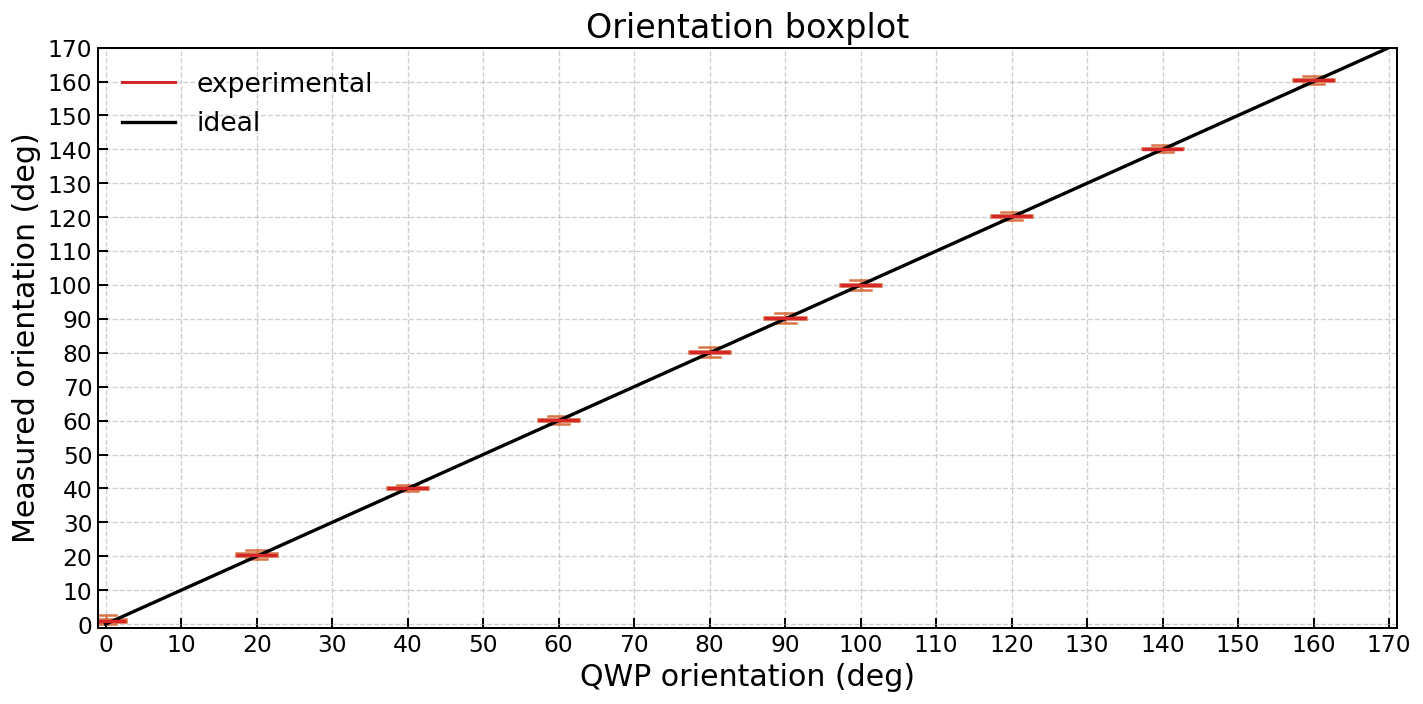

In [14]:
# %% =============================
# Cell 12: orientation boxplot
# freely adjustable colors for box / whisker / median / ideal / experimental
# uses STYLE from Cell 11, but color parameters are defined here
# =============================
ORIENTATION_PLOT = {
    "box_facecolor": "#f4c79a",
    "box_edgecolor": "#d77649",
    "box_linewidth": 1.5,

    "whisker_color": "#d77649",
    "whisker_linewidth": 1.5,

    "cap_color": "#d77649",
    "cap_linewidth": 1.5,

    "median_color": "#d62728",
    "median_linewidth": 2.0,

    "ideal_color": "black",
    "ideal_linestyle": "-",
    "ideal_linewidth": 2.0,

    "experimental_color": "#d62728",
    "experimental_linewidth": 1.8,
}

positions = np.array(qwp_angles, dtype=float)

fig, ax = plt.subplots(figsize=(12, 6))   # 只把图加宽，避免 tick label 挤

bp = ax.bxp(
    orientation_bxp,
    positions=positions,
    widths=5.5,
    showfliers=False,
    patch_artist=True,
    manage_ticks=False,
    boxprops=dict(
        facecolor=ORIENTATION_PLOT["box_facecolor"],
        edgecolor=ORIENTATION_PLOT["box_edgecolor"],
        linewidth=ORIENTATION_PLOT["box_linewidth"]
    ),
    whiskerprops=dict(
        color=ORIENTATION_PLOT["whisker_color"],
        linewidth=ORIENTATION_PLOT["whisker_linewidth"]
    ),
    capprops=dict(
        color=ORIENTATION_PLOT["cap_color"],
        linewidth=ORIENTATION_PLOT["cap_linewidth"]
    ),
    medianprops=dict(
        color=ORIENTATION_PLOT["median_color"],
        linewidth=ORIENTATION_PLOT["median_linewidth"]
    )
)

exp_handle, = ax.plot(
    [], [],
    color=ORIENTATION_PLOT["experimental_color"],
    linewidth=ORIENTATION_PLOT["experimental_linewidth"],
    label="experimental"
)

ideal_handle, = ax.plot(
    [0, 170],
    [0, 170],
    color=ORIENTATION_PLOT["ideal_color"],
    linestyle=ORIENTATION_PLOT["ideal_linestyle"],
    linewidth=ORIENTATION_PLOT["ideal_linewidth"],
    label="ideal"
)

ax.set_xlim(-1, 171)
ax.set_ylim(-1, 170)

xticks = np.arange(0, 171, 10)
yticks = np.arange(0, 171, 10)

ax.set_xticks(xticks)
ax.set_xticklabels([str(x) for x in xticks])
ax.set_yticks(yticks)

ax.set_xlabel("QWP orientation (deg)", fontsize=STYLE["label_fontsize"])
ax.set_ylabel("Measured orientation (deg)", fontsize=STYLE["label_fontsize"])
ax.set_title("Orientation boxplot", fontsize=STYLE["title_fontsize"])

ax.tick_params(
    axis='both',
    which='major',
    direction=STYLE["tick_direction"],
    length=STYLE["tick_major_length"],
    width=STYLE["tick_major_width"],
    labelsize=STYLE["tick_labelsize"]
)

# 关键：不要开 x minor tick
ax.tick_params(axis='x', which='minor', bottom=False, top=False)
ax.tick_params(axis='y', which='minor', left=False, right=False)

if STYLE["grid"]:
    ax.grid(
        True,
        which='major',
        linestyle=STYLE["grid_linestyle"],
        linewidth=STYLE["grid_linewidth"],
        alpha=STYLE["grid_alpha"]
    )

if STYLE["legend_bbox_to_anchor"] is None:
    ax.legend(
        handles=[exp_handle, ideal_handle],
        loc=STYLE["legend_loc"],
        fontsize=STYLE["legend_fontsize"],
        frameon=STYLE["legend_frameon"],
        ncol=STYLE["legend_ncol"]
    )
else:
    ax.legend(
        handles=[exp_handle, ideal_handle],
        loc=STYLE["legend_loc"],
        bbox_to_anchor=STYLE["legend_bbox_to_anchor"],
        fontsize=STYLE["legend_fontsize"],
        frameon=STYLE["legend_frameon"],
        ncol=STYLE["legend_ncol"]
    )

plt.tight_layout()
plt.show()

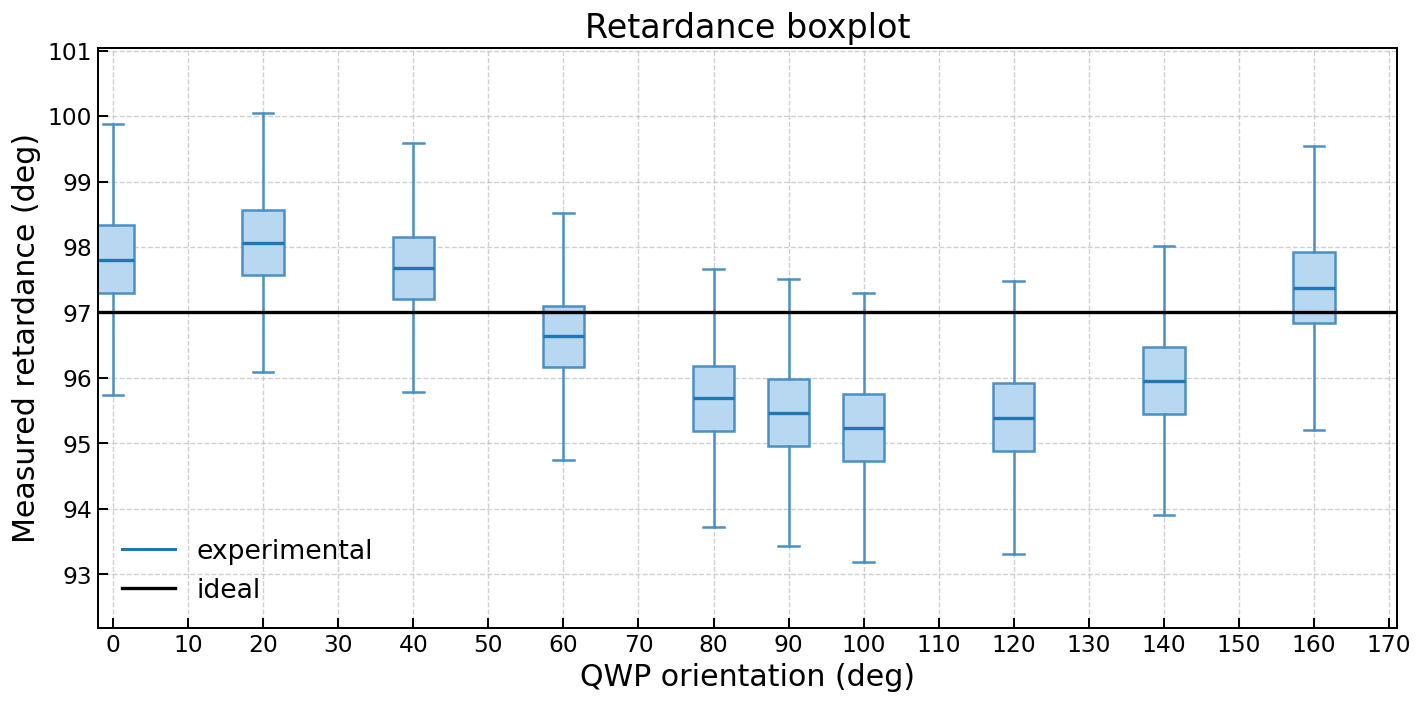

In [15]:
# %% =============================
# Cell 13: retardance boxplot
# freely adjustable colors for box / whisker / median / ideal / experimental
# uses STYLE from Cell 11, but color parameters are defined here
# =============================
RETARDANCE_PLOT = {
    "box_facecolor": "#b7d8f0",
    "box_edgecolor": "#4a90c2",
    "box_linewidth": 1.5,

    "whisker_color": "#4a90c2",
    "whisker_linewidth": 1.5,

    "cap_color": "#4a90c2",
    "cap_linewidth": 1.5,

    "median_color": "#1f77b4",
    "median_linewidth": 2.0,

    "ideal_color": "black",
    "ideal_linestyle": "-",
    "ideal_linewidth": 2.0,

    "experimental_color": "#1f77b4",
    "experimental_linewidth": 1.8,
}

positions = np.array(qwp_angles, dtype=float)

fig, ax = plt.subplots(figsize=(12, 6))   # 同样加宽

bp = ax.bxp(
    retardation_bxp,
    positions=positions,
    widths=5.5,
    showfliers=False,
    patch_artist=True,
    manage_ticks=False,
    boxprops=dict(
        facecolor=RETARDANCE_PLOT["box_facecolor"],
        edgecolor=RETARDANCE_PLOT["box_edgecolor"],
        linewidth=RETARDANCE_PLOT["box_linewidth"]
    ),
    whiskerprops=dict(
        color=RETARDANCE_PLOT["whisker_color"],
        linewidth=RETARDANCE_PLOT["whisker_linewidth"]
    ),
    capprops=dict(
        color=RETARDANCE_PLOT["cap_color"],
        linewidth=RETARDANCE_PLOT["cap_linewidth"]
    ),
    medianprops=dict(
        color=RETARDANCE_PLOT["median_color"],
        linewidth=RETARDANCE_PLOT["median_linewidth"]
    )
)

exp_handle, = ax.plot(
    [], [],
    color=RETARDANCE_PLOT["experimental_color"],
    linewidth=RETARDANCE_PLOT["experimental_linewidth"],
    label="experimental"
)

ideal_handle = ax.axhline(
    y=97,
    color=RETARDANCE_PLOT["ideal_color"],
    linestyle=RETARDANCE_PLOT["ideal_linestyle"],
    linewidth=RETARDANCE_PLOT["ideal_linewidth"],
    label="ideal"
)

ax.set_xlim(-2, 171)

all_ret_values = []
for d in retardation_bxp:
    all_ret_values.extend([d["whislo"], d["q1"], d["med"], d["q3"], d["whishi"]])

ymin = min(all_ret_values + [97])
ymax = max(all_ret_values + [97])
margin = max(1, 0.08 * (ymax - ymin))
ax.set_ylim(ymin - margin, ymax + margin)

xticks = np.arange(0, 171, 10)
ax.set_xticks(xticks)
ax.set_xticklabels([str(x) for x in xticks])

ax.set_xlabel("QWP orientation (deg)", fontsize=STYLE["label_fontsize"])
ax.set_ylabel("Measured retardance (deg)", fontsize=STYLE["label_fontsize"])
ax.set_title("Retardance boxplot", fontsize=STYLE["title_fontsize"])

ax.tick_params(
    axis='both',
    which='major',
    direction=STYLE["tick_direction"],
    length=STYLE["tick_major_length"],
    width=STYLE["tick_major_width"],
    labelsize=STYLE["tick_labelsize"]
)

# 不开 minor tick，避免“很密”
ax.tick_params(axis='x', which='minor', bottom=False, top=False)
ax.tick_params(axis='y', which='minor', left=False, right=False)

if STYLE["grid"]:
    ax.grid(
        True,
        which='major',
        linestyle=STYLE["grid_linestyle"],
        linewidth=STYLE["grid_linewidth"],
        alpha=STYLE["grid_alpha"]
    )

if STYLE["legend_bbox_to_anchor"] is None:
    ax.legend(
        handles=[exp_handle, ideal_handle],
        loc=STYLE["legend_loc"],
        fontsize=STYLE["legend_fontsize"],
        frameon=STYLE["legend_frameon"],
        ncol=STYLE["legend_ncol"]
    )
else:
    ax.legend(
        handles=[exp_handle, ideal_handle],
        loc=STYLE["legend_loc"],
        bbox_to_anchor=STYLE["legend_bbox_to_anchor"],
        fontsize=STYLE["legend_fontsize"],
        frameon=STYLE["legend_frameon"],
        ncol=STYLE["legend_ncol"]
    )

plt.tight_layout()
plt.show()

QWP   0° -> retardance at (x=1000, y=1000) = 97.32270812988281
QWP  20° -> retardance at (x=1000, y=1000) = 97.33702087402344
QWP  40° -> retardance at (x=1000, y=1000) = 98.40129089355469
QWP  60° -> retardance at (x=1000, y=1000) = 98.75228118896484
QWP  80° -> retardance at (x=1000, y=1000) = 96.70072937011719
QWP  90° -> retardance at (x=1000, y=1000) = 95.65707397460938
QWP 100° -> retardance at (x=1000, y=1000) = 96.19618225097656
QWP 120° -> retardance at (x=1000, y=1000) = 95.16094970703125
QWP 140° -> retardance at (x=1000, y=1000) = 94.2389907836914
QWP 160° -> retardance at (x=1000, y=1000) = 96.71043395996094


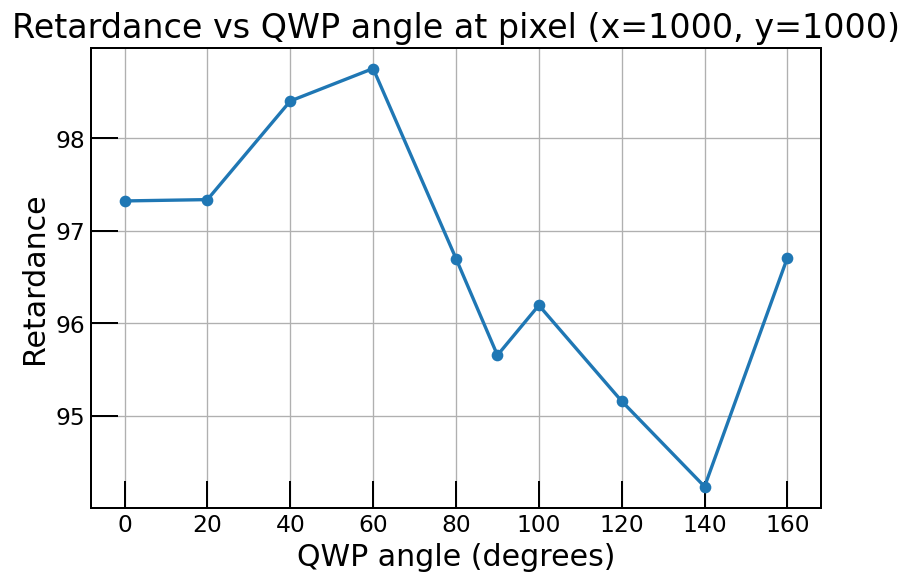

In [16]:
# %% =============================
# Cell 4: plot retardance change of a single pixel
# =============================
x, y = 1000,1000   # pixel coordinate

pixel_retardance = []
valid_angles = []

for angle in qwp_angles:
    img = retardation_imgs[angle]

    # check bounds
    h, w = img.shape
    if 0 <= y < h and 0 <= x < w:
        value = img[y, x]   # numpy image indexing: [row, col] = [y, x]
        pixel_retardance.append(value)
        valid_angles.append(angle)
        print(f"QWP {angle:>3}° -> retardance at (x={x}, y={y}) = {value}")
    else:
        print(f"QWP {angle:>3}° -> pixel (x={x}, y={y}) is out of bounds for image shape {img.shape}")

# plot
plt.figure(figsize=(7,5))
plt.plot(valid_angles, pixel_retardance, marker='o', linewidth=2)
plt.xlabel("QWP angle (degrees)")
plt.ylabel("Retardance")
plt.title(f"Retardance vs QWP angle at pixel (x={x}, y={y})")
plt.grid(True)
plt.tight_layout()
plt.show()